In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
complexes_df = pd.read_csv('../data/rag_results/complexes_results.csv')
oxazo_df = pd.read_csv('../data/rag_results/oxazo_results.csv')
nanozymes_df = pd.read_csv('../data/rag_results/nanozymes_results.csv')

In [6]:
metrics_columns = [
        'bert_score_recall',
        'cosine_similarity',
        'golden_doi_mrr',
        'golden_doi_recall',
        'numeric_recall',
        'rouge_l_recall',
        'scientific_fact_recall',
        'source_support_hit',
        'source_support_max_similarity',
        'token_f1',
        'token_recall'
    ]

In [7]:
def plot_metric_histograms(df):
    ncols = 4
    nrows = (11 + ncols - 1) // ncols
    
    plt.figure(figsize=(5 * ncols, 4 * nrows))
    
    for i, col in enumerate(metrics_columns, 1):
        plt.subplot(nrows, ncols, i)
        df[col].dropna().hist(bins=30)
        plt.title(col)
        plt.xlabel('Value')
        plt.ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()

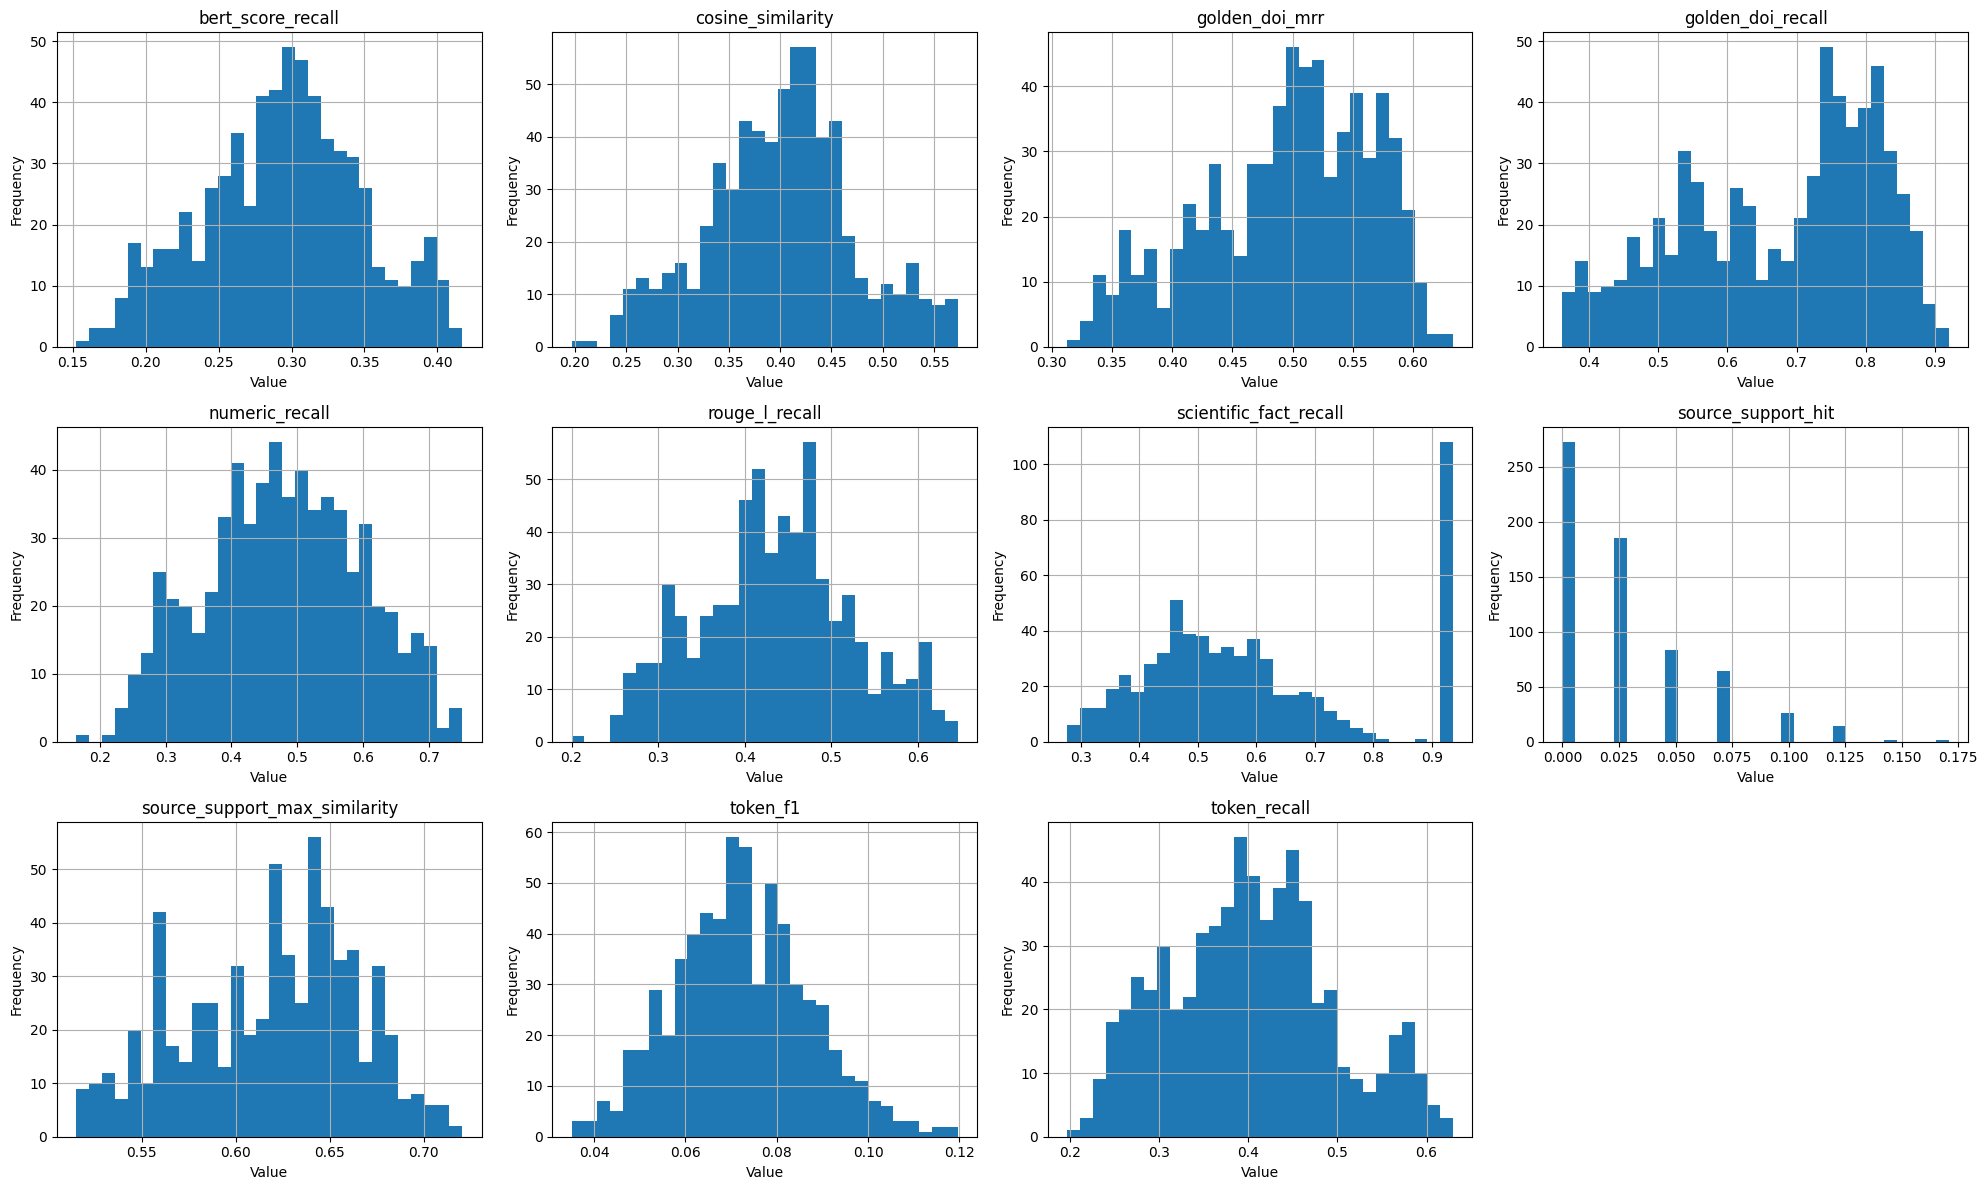

In [5]:
plot_metric_histograms(complexes_df)

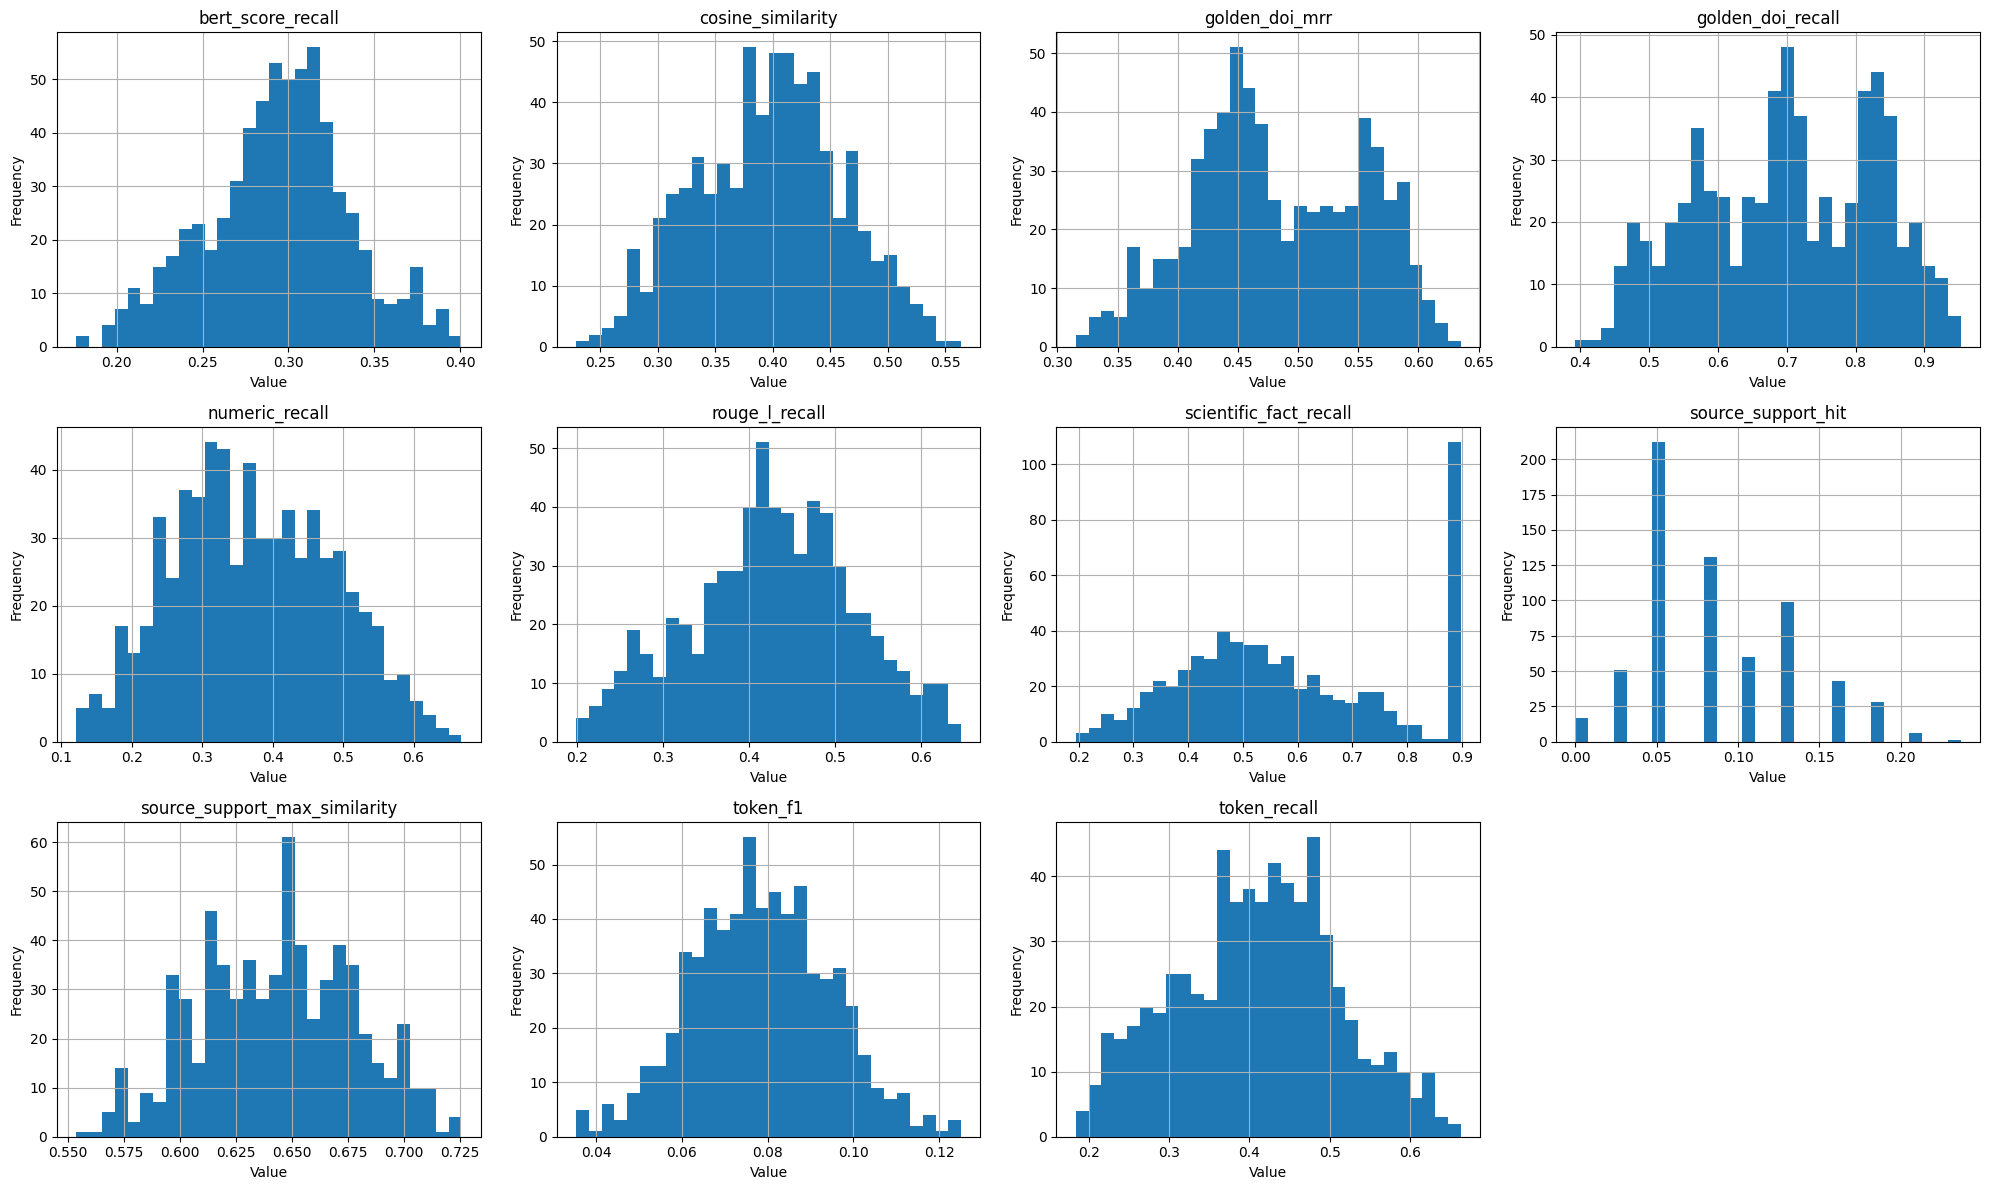

In [6]:
plot_metric_histograms(oxazo_df)

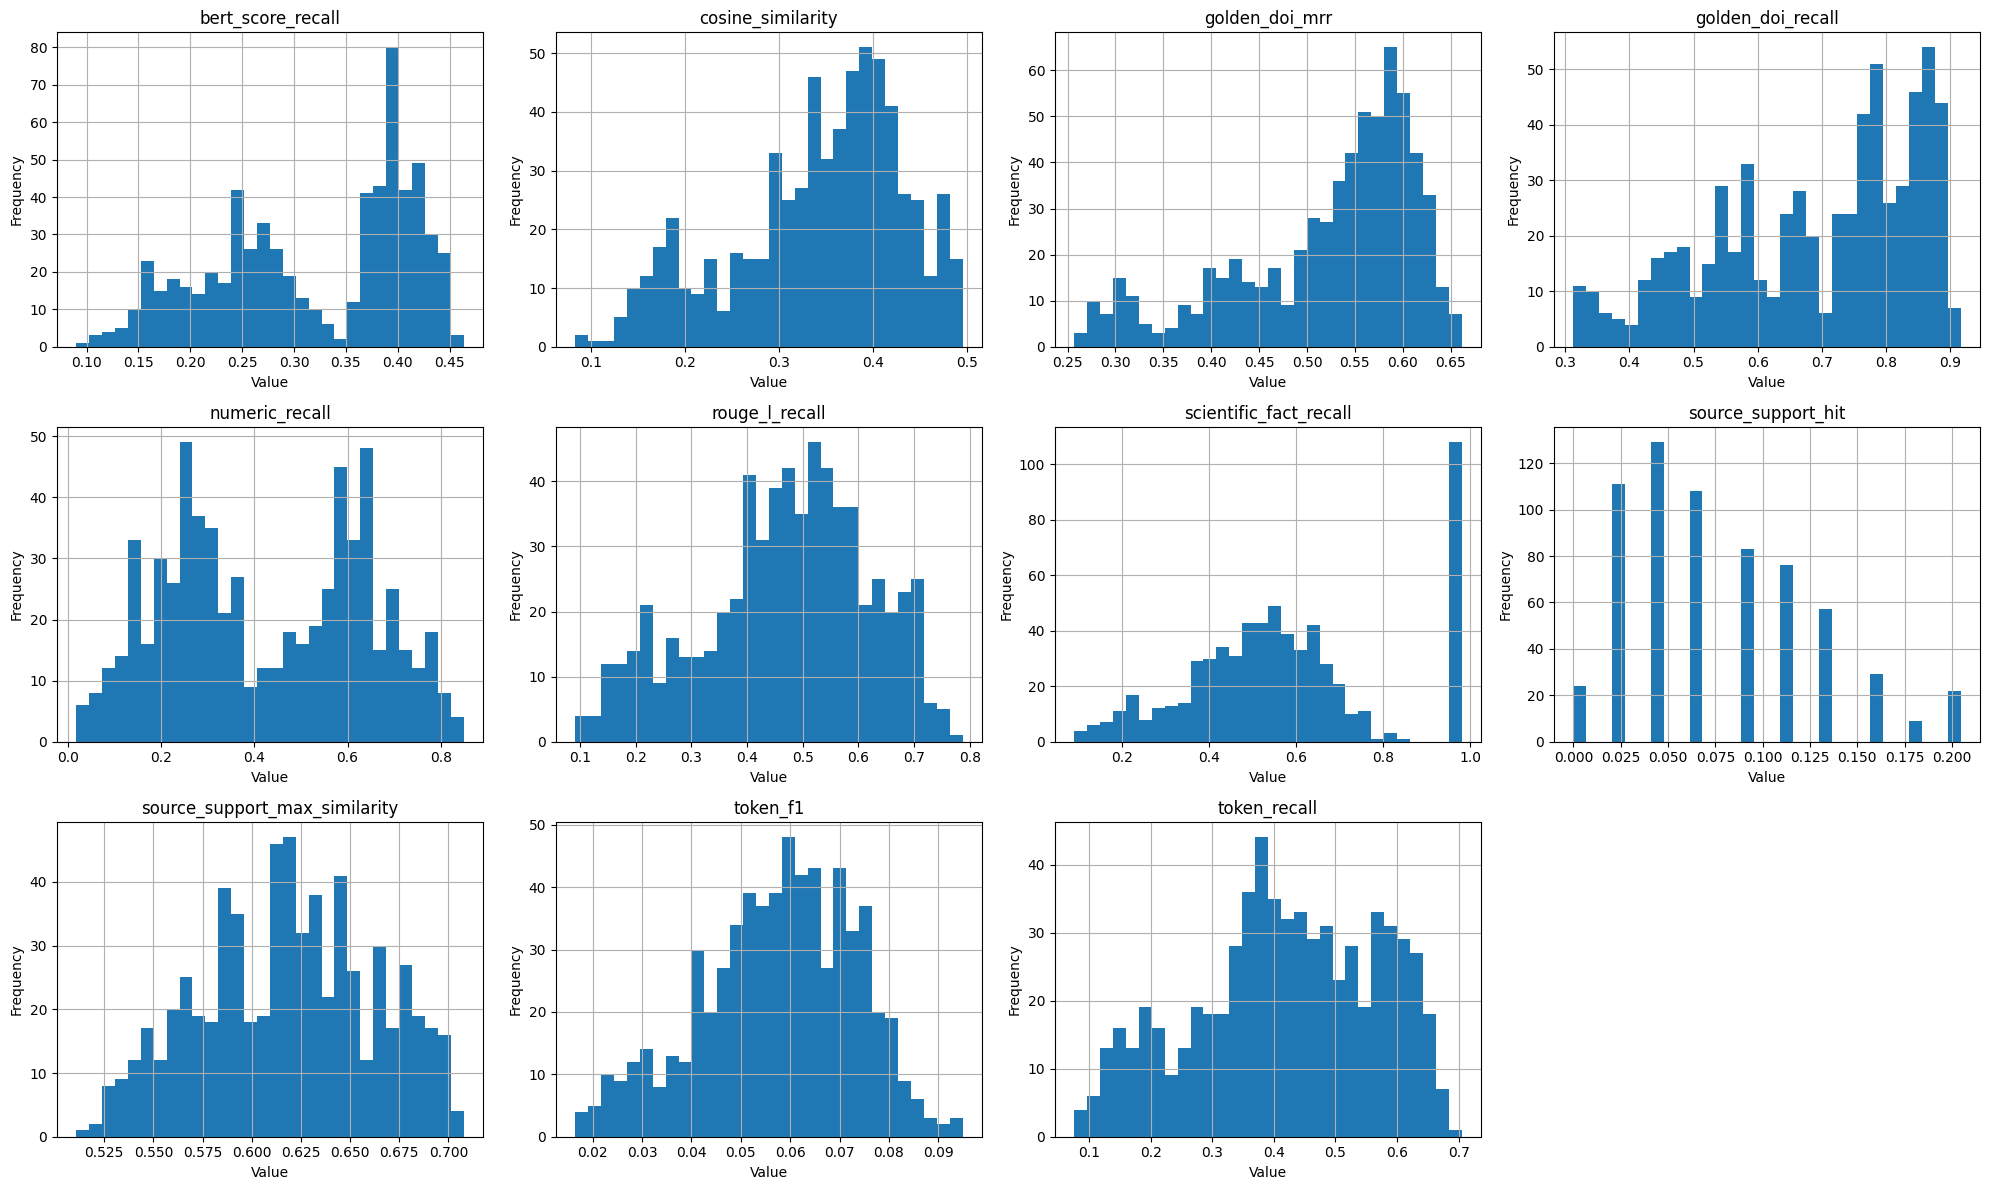

In [9]:
plot_metric_histograms(nanozymes_df)

In [24]:
best_row_oxazo = oxazo_df.loc[
    (oxazo_df['golden_doi_recall'] + oxazo_df['scientific_fact_recall']).idxmax()
]
best_row_oxazo.to_dict()

{'corpus': 'oxazo',
 'kb_alias': 'cs500_ct1_pf1_tg1',
 'eval_alias': 'dk20_sk20_hybrid_zerank_mistral',
 'chunk_size': 500,
 'chunk_overlap': 125,
 'count_tokens': True,
 'paragraph_filtrator': True,
 'table_grabber': True,
 'dense_k': 20,
 'sparse_k': 20,
 'search_mode': 'hybrid',
 'reranker': 'zerank-1',
 'llm_model': 'mistral-small3.2',
 'bert_score_recall': 0.3852427612457956,
 'cosine_similarity': 0.505800944624335,
 'golden_doi_mrr': 0.5811471900734094,
 'golden_doi_recall': 0.952721088435374,
 'numeric_recall': 0.5529040404040404,
 'rouge_l_recall': 0.6090471900690296,
 'scientific_fact_recall': 0.8954318562373725,
 'source_support_hit': 0.1842105263157894,
 'source_support_max_similarity': 0.6971702562069743,
 'token_f1': 0.0962399857878096,
 'token_recall': 0.6154821804021202}

In [ ]:
top10_oxazo = oxazo_df.assign(
    score=oxazo_df['golden_doi_recall'] + oxazo_df['scientific_fact_recall']
).sort_values(by='score', ascending=False).head(10)
top10_oxazo.to_json('top10_oxazo.json', orient='records', indent=2, force_ascii=False)

In [9]:
best_row_complexes = complexes_df.loc[
    (complexes_df['golden_doi_recall'] + complexes_df['scientific_fact_recall']).idxmax()
]
best_row_complexes.to_dict()

{'corpus': 'complexes',
 'kb_alias': 'cs300_ct1_pf1_tg1',
 'eval_alias': 'dk20_sk20_hybrid_zerank_mistral',
 'chunk_size': 300,
 'chunk_overlap': 75,
 'count_tokens': True,
 'paragraph_filtrator': True,
 'table_grabber': True,
 'dense_k': 20,
 'sparse_k': 20,
 'search_mode': 'hybrid',
 'reranker': 'zerank-1',
 'llm_model': 'mistral-small3.2',
 'bert_score_recall': 0.3734423709767205,
 'cosine_similarity': 0.4944206722877166,
 'golden_doi_mrr': 0.5772544475447515,
 'golden_doi_recall': 0.8888888888888888,
 'numeric_recall': 0.6805555555555556,
 'rouge_l_recall': 0.541784741208921,
 'scientific_fact_recall': 0.9356314870095932,
 'source_support_hit': 0.1219512195121951,
 'source_support_max_similarity': 0.6936401151622761,
 'token_f1': 0.0884171348174417,
 'token_recall': 0.5264423219321731}

In [27]:
top10_complexes = complexes_df.assign(
    score=complexes_df['golden_doi_recall'] + complexes_df['scientific_fact_recall']
).sort_values(by='score', ascending=False).head(10)
top10_complexes.to_json('top10_complexes.json', orient='records', indent=2, force_ascii=False)

In [21]:
best_row_nanozymes = nanozymes_df.loc[
    (nanozymes_df['golden_doi_recall'] + nanozymes_df['scientific_fact_recall']).idxmax()
]
best_row_nanozymes.to_dict()

{'corpus': 'nano',
 'kb_alias': 'cs800_ct1_pf1_tg1',
 'eval_alias': 'dk20_sk20_hybrid_zerank_mistral',
 'chunk_size': 800,
 'chunk_overlap': 200,
 'count_tokens': True,
 'paragraph_filtrator': True,
 'table_grabber': True,
 'dense_k': 20,
 'sparse_k': 20,
 'search_mode': 'hybrid',
 'reranker': 'zerank-1',
 'llm_model': 'mistral-small3.2',
 'bert_score_recall': 0.4460898893220084,
 'cosine_similarity': 0.4866459543529728,
 'golden_doi_mrr': 0.5911058125901876,
 'golden_doi_recall': 0.8958333333333334,
 'numeric_recall': 0.8117283950617284,
 'rouge_l_recall': 0.7091764137228034,
 'scientific_fact_recall': 0.9805364567445346,
 'source_support_hit': 0.1136363636363636,
 'source_support_max_similarity': 0.6542463621940744,
 'token_f1': 0.0795644889689271,
 'token_recall': 0.6522807589075338}

In [28]:
top10_nano = nanozymes_df.assign(
    score=nanozymes_df['golden_doi_recall'] + nanozymes_df['scientific_fact_recall']
).sort_values(by='score', ascending=False).head(10)
top10_nano.to_json('top10_nano.json', orient='records', indent=2, force_ascii=False)

In [29]:
metrics = [
    'bert_score_recall',
    'cosine_similarity',
    'golden_doi_mrr',
    'golden_doi_recall',
    'rouge_l_recall',
    'scientific_fact_recall'
]

top10_oxazo = (
    oxazo_df
    .assign(score=oxazo_df[metrics].sum(axis=1))
    .sort_values(by='score', ascending=False)
    .head(10)
)

# сохранить в JSON
top10_oxazo.to_json('top10_oxazo_6_metrics.json', orient='records', indent=2, force_ascii=False)

In [30]:
top10_complexes = (
    complexes_df
    .assign(score=complexes_df[metrics].sum(axis=1))
    .sort_values(by='score', ascending=False)
    .head(10)
)

# сохранить в JSON
top10_complexes.to_json('top10_complexes_6_metrics.json', orient='records', indent=2, force_ascii=False)

In [31]:
top10_nano = (
    nanozymes_df
    .assign(score=nanozymes_df[metrics].sum(axis=1))
    .sort_values(by='score', ascending=False)
    .head(10)
)

# сохранить в JSON
top10_nano.to_json('top10_nano_6_metrics.json', orient='records', indent=2, force_ascii=False)

In [3]:
df = pd.read_csv("../data/oxazo_results_per_question.csv")

In [4]:
df.columns

Index(['corpus', 'kb_alias', 'eval_alias', 'chunk_size', 'chunk_overlap',
       'count_tokens', 'paragraph_filtrator', 'table_grabber', 'dense_k',
       'sparse_k', 'search_mode', 'reranker', 'llm_model', 'session_id',
       'scenario_type', 'turn_index', 'question_id', 'question',
       'golden_answer', 'generated_answer', 'execution_time_seconds',
       'bert_score_recall', 'cosine_similarity', 'golden_doi_mrr',
       'golden_doi_recall', 'numeric_recall', 'rouge_l_recall',
       'scientific_fact_recall', 'source_support_hit',
       'source_support_max_similarity', 'token_f1', 'token_recall',
       'num_retrieved_chunks', 'chunk_scores', 'chunk_avg_score',
       'chunk_max_score', 'chunk_min_score', 'chunk_unique_articles',
       'chunk_article_keys', 'num_retrieved_images', 'image_unique_articles',
       'image_article_keys'],
      dtype='str')

In [9]:
for i, row in df.iterrows():
    print("===============")
    print(row["question"])
    print(row["golden_answer"])
    print(row["generated_answer"])
    if i==10:
        break

What is the inhibition constant of linezolid for the 30S ribosomal unit?
Linezolid does not inhibit 30S ribosomal subunit
I did not find relevant information in the knowledge base.
What is the MIC of linezolid against S. aureus ATCC 25923 according to Molecules journal data?
2 μg/mL
The **Molecules** journal reports that linezolid has a minimum inhibitory concentration (MIC) of **2 µg mL⁻¹** against *Staphylococcus aureus* ATCC 25923.  

*Source: “Synthesis, Antibacterial and Anthelmintic Activity of Novel 3-(3‑Pyridyl)-oxazolidinone‑5‑methyl Ester Derivatives” (Molecules, 2022).*
What is the minimum inhibitory concentration of thiamphenicol for the Enterococcus faecalis ΔlsaA strain expressing the PoxtA AOUC-0915 variant?
32-64 µg/mL
nan
What amino acid residues are present in the penultimate position of the nascent peptide chain when mitochondrial ribosomes stall in the presence of chloramphenicol and linezolid?
alanine, serine, or threonine
The mitochondrial ribosome stalls at speci